# XGBoost Classifier — Binary Classification (Second-Order Gradient Boosting with Regularization)

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

and

$$
y_i \in \{0,1\}
$$

The goal is to learn a function that predicts the probability of the positive class.

---

## 2. Model Idea

XGBoost builds an additive model over functions:

$$
F(x) = \sum_{m=1}^{M} \eta \, f_m(x)
$$

where each $f_m(x)$ is a decision tree and $\eta$ is the learning rate.

Final probabilities are obtained using the sigmoid function:

$$
P(y = 1 \mid x) = \frac{1}{1 + \exp(-F(x))}
$$

---

## 3. Initialization

Initialize predictions in log-odds space:

$$
F^{(0)}(x) = 0
$$

Thus initial probabilities:

$$
p_i = \frac{1}{2}
$$

---

## 4. Loss Function

XGBoost minimizes binary cross-entropy loss:

$$
\mathcal{L} = \sum_{i=1}^{N} \left[ -y_i \log(p_i) - (1 - y_i)\log(1 - p_i) \right]
$$

---

## 5. Second-Order Approximation

XGBoost uses a second-order Taylor expansion of the loss:

$$
\mathcal{L}^{(m)} \approx \sum_{i=1}^{N} \left[ g_i f_m(x_i) + \frac{1}{2} h_i f_m(x_i)^2 \right] + \Omega(f_m)
$$

where

$$
g_i = \frac{\partial \mathcal{L}}{\partial F(x_i)}, \quad
h_i = \frac{\partial^2 \mathcal{L}}{\partial F(x_i)^2}
$$

---

## 6. Gradient and Hessian

For binary classification:

$$
g_i = p_i - y_i
$$

$$
h_i = p_i (1 - p_i)
$$

These guide how the next tree should correct the current model.

---

## 7. Tree Structure and Leaf Weights

Each tree partitions the data into regions (leaves). For a leaf $j$:

$$
G_j = \sum_{i \in I_j} g_i, \quad
H_j = \sum_{i \in I_j} h_i
$$

The optimal leaf weight is:

$$
w_j = - \frac{G_j}{H_j + \lambda}
$$

where $\lambda$ is L2 regularization.

---

## 8. Split Gain

To decide the best split, XGBoost computes the gain:

$$
\text{Gain} = \frac{1}{2} \left(
\frac{G_L^2}{H_L + \lambda} +
\frac{G_R^2}{H_R + \lambda} -
\frac{G^2}{H + \lambda}
\right) - \gamma
$$

where:
- $\gamma$ penalizes complex trees  
- Split is accepted only if Gain $> 0$

---

## 9. Additive Model Update

Each tree is added to the model with learning rate $\eta$, controlling the contribution of each tree.

$$
F(x) \leftarrow F(x) + \eta \, f_m(x)
$$

---

## 10. Prediction from Trees

Each tree outputs a constant value for a region:

$$
f_m(x) = w_j \quad \text{if } x \in \text{leaf } j
$$

---

## 11. Final Prediction

Final score:

$$
F(x) = \sum_{m=1}^{M} \eta \, f_m(x)
$$

Convert to probability:

$$
P(y = 1 \mid x) = \frac{1}{1 + \exp(-F(x))}
$$

Final class:

$$
\hat{y} =
\begin{cases}
1 & \text{if } P(y = 1 \mid x) \geq 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

---

## 12. Regularization

XGBoost includes:

- $\lambda$: L2 regularization on leaf weights  
- $\gamma$: penalty for adding new splits  

These help prevent overfitting.

---

## 13. Feature Subsampling

At each split, a subset of features is randomly selected:

$$
\text{features} \subseteq \{1,2,\dots,D\}
$$

This improves generalization and reduces variance.

---

## 14. Algorithm Summary

For $m = 1$ to $M$:

$$
\text{Compute probabilities } p_i = \sigma(F(x_i))
$$

$$
\text{Compute gradients } g_i = p_i - y_i
$$

$$
\text{Compute hessians } h_i = p_i(1 - p_i)
$$

$$
\text{Fit tree } f_m(x) \text{ using } g_i, h_i
$$

$$
F(x) \leftarrow F(x) + \eta \, f_m(x)
$$

---

## 15. Intuition

- Fits trees to gradients (errors of current model)  
- Uses second-order information for better optimization  
- Regularization controls model complexity  
- Learning rate ensures stable and gradual learning  
- Combines multiple weak trees into a strong learner

---

In [7]:
class LeafNode:
    """
    Represents a terminal leaf in the XGBoost tree.
    """
    def __init__(self,weights):
        # The leaf value (weight) that contributes to the final prediction.
        # In XGBoost, this is the optimized value that minimizes the loss function 
        # for the samples falling into this region.
        self.weights = weights

In [8]:
class DecisionNode:
    """
    Represents an internal split point within the XGBoost tree.
    """
    def __init__(self, best_feature , best_threshold , left_child , right_child):
        # The index of the column/feature chosen for the split
        self.best_feature = best_feature
        # The specific value used to divide the samples
        self.best_threshold = best_threshold
        # The node representing the 'True' (<= threshold) branch
        self.left_child = left_child
        # The node representing the 'False' (> threshold) branch
        self.right_child = right_child

In [83]:
class XGBoostTree:
    """
    A single decision tree for XGBoost that optimizes the structure score.
    
    Attributes:
        max_depth (int): Maximum depth of the tree.
        min_samples_split (int): Minimum samples required to split a node.
        feature_fraction (float): Percentage of features to consider per split.
        gamma (float): Minimum gain required to make a further partition.
        lambda_ (float): L2 regularization term on weights.
        root (Node): The root node of the trained tree.
    """
    def __init__(self, max_depth = 10, min_samples_split = 1, feature_fraction=1, gamma = 1 , lambda_ =1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_fraction = feature_fraction
        self.gamma = gamma
        self.lambda_ = lambda_

        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")
        
        self.root = None
        self.X = None
        self.g = None
        self.h = None

    def _stopping_condition(self,indices,depth):
        """Checks if the tree growth should stop based on depth or sample count."""
        if depth >= self.max_depth:
            return True
        if len(indices)< self.min_samples_split:
            return True
        return False
        
    def _feature_sampling(self):
        """Randomly selects a subset of features based on feature_fraction."""
        num_sampled_features = max(1, int(round(self.feature_fraction * self.num_features)))
        selected_features = np.random.choice(self.num_features,num_sampled_features,replace=False)

        return selected_features

    def _find_all_thresholds(self,selected_features,indices):
        """Generates candidate split points (averages of unique values) for each feature."""
        all_thresholds = []
        for feature in selected_features:
            unique_vals = np.unique(self.X[indices , feature])
            if len(unique_vals) ==1:
                all_thresholds.append(np.array([]))
            else:
                averages = (unique_vals[1:]+ unique_vals[:-1])/2

                all_thresholds.append(averages)

        return all_thresholds

    def _split(self,feature,threshold,indices):
        """Divides indices into left and right groups based on a threshold."""
        condition = self.X[indices,feature]<=threshold
        left_indices = indices[condition]
        right_indices = indices[~condition]

        return left_indices , right_indices

    def _leaf_value(self,G,H):
        """Calculates the optimal weight (output) for a leaf node."""
        return - G / (H + self.lambda_ +1e-10)

    def _computeGH(self,indices):
        """Returns the sum of gradients (G) and hessians (H) for a set of indices."""
        return np.sum(self.g[indices]) , np.sum(self.h[indices])

    def _calc_gain_term(self,G,H):
        """Calculates the similarity score for a specific node grouping."""
        return G**2/(H + self.lambda_ + 1e-10)

    def _compute_score(self,left_gain,right_gain, node_gain):
        """Calculates the final Gain of a split including the gamma penalty."""
        return 0.5*(left_gain + right_gain -node_gain) - self.gamma

    def _best_feature_threshold(self,selected_features,all_thresholds,indices):
        """Iterates through features and thresholds to find the highest Gain split."""
        best_feature = None
        best_threshold = None
        best_gain = - np.inf
        # Pre-calculate G and H for the current node to use in Gain formula
        G_node , H_node = self._computeGH(indices)
        node_gain = self._calc_gain_term(G_node,H_node)

        for i,feature in enumerate(selected_features):
            threshold_for_feature = all_thresholds[i]
            # Skip features with no valid split points
            if len(threshold_for_feature)==0:
                continue
            feature_values = self.X[indices , feature]
            for threshold in threshold_for_feature:
                # Divide data into potential left/right branches
                condition = feature_values <= threshold
                left_indices , right_indices = indices[condition] , indices[~condition]
                # Ensure the split actually separates the data
                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue
                # Calculate G and H for children
                G_L , H_L = self._computeGH(left_indices)
                G_R , H_R = self._computeGH(right_indices)
                # Compute individual gain terms
                left_gain = self._calc_gain_term(G_L , H_L)
                right_gain = self._calc_gain_term(G_R , H_R)
                # Calculate total Gain (includes Gamma penalty)
                score = self._compute_score(left_gain,right_gain,node_gain)
                # Update best split found so far
                if score > best_gain:
                    best_gain = score
                    best_feature = feature
                    best_threshold = threshold

        return best_feature , best_threshold , best_gain

    def _find_best_split(self,indices):
        """
        Coordinates the split discovery process by sampling features and 
        evaluating potential thresholds.
        
        Args:
            indices (ndarray): The row indices of the data currently being 
                               processed at this node.
                               
        Returns:
            best_feature (int/str): The index of the feature to split on.
            best_threshold (float): The value to split the feature on.
            best_gain (float): The maximum gain score achieved.
        """
        # Apply column subsampling
        selected_features = self._feature_sampling()
        # Identify candidate split points for the sampled features
        all_thresholds = self._find_all_thresholds(selected_features,indices)
        # Evaluate Gain for all candidates to find the winner
        best_feature , best_threshold , best_gain = self._best_feature_threshold(selected_features,all_thresholds,indices)

        return best_feature , best_threshold , best_gain

    def _build_tree(self,indices,depth):
        """Recursive function to build the tree nodes."""
        G , H = self._computeGH(indices)

        if self._stopping_condition(indices,depth):
            return LeafNode(self._leaf_value(G,H))

        best_feature , best_threshold , best_gain = self._find_best_split(indices)

        if best_gain <=0:
            return LeafNode(self._leaf_value(G,H))

        left_indices , right_indices = self._split(best_feature,best_threshold,indices)

        left_child = self._build_tree(left_indices, depth+1)
        right_child = self._build_tree(right_indices, depth+1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self,X,g,h):
        """
        Initializes the training process and builds the tree.
        
        Args:
            X (ndarray): Feature matrix.
            g (ndarray): Gradients of the loss function.
            h (ndarray): Hessians of the loss function.
        """
        X = np.asarray(X)
        g = np.asarray(g)
        h = np.asarray(h)

        self.X = X
        self.g = g
        self.h = h

        N , self.num_features = self.X.shape

        indices = np.arange(N)

        self.root = self._build_tree(indices,0)

    def _predict_single(self, x, node):
        """Helper to navigate a single row through the tree to a leaf."""
        if isinstance(node, LeafNode):
            return node.weights
        else:
            if x[node.best_feature] <= node.best_threshold:
                return self._predict_single(x,node.left_child)
            else:
                return self._predict_single(x,node.right_child)

    def _count_leaves(self,node):
        """Helper to count number of leaves"""
        if isinstance(node,LeafNode):
            return 1
        else :
            return self._count_leaves(node.left_child) + self._count_leaves(node.right_child)

    def predict(self,X):
        """Predicts leaf weights for the input matrix X."""
        y_pred = np.array([self._predict_single(x, self.root) for x in X])

        return y_pred

In [122]:
class XGBoostClassifier:
    """
    A Gradient Boosting classifier using XGBoostTrees as base learners.
    
    Attributes:
        n_estimators (int): Number of boosting rounds (trees to build).
        max_depth (int): Maximum depth for each individual tree.
        learning_rate (float): Step size shrinkage used to prevent overfitting (eta).
        all_models (list): Storage for all trained XGBoostTree instances.
    """
    def __init__(self,n_estimators=10 , max_depth = 10, min_samples_split = 1, feature_fraction=1, gamma = 1 , lambda_ =1, learning_rate=0.01, random_state=42):
        
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_fraction = feature_fraction
        self.gamma  = gamma
        self.lambda_ = lambda_
        self.learning_rate = learning_rate
        self.random_state= random_state

        self.all_models = None

        # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N estimators must be a positive integer')   
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")

    def _sigmoid(self,y):
        """
        Numerically stable sigmoid function to convert log-odds to probabilities.
        Handles large positive/negative values to avoid overflow.
        """
        output = np.zeros_like(y, dtype=float)

        pos_indices = y>0
        neg_indices = ~pos_indices
        # Standard sigmoid for positive values
        output[pos_indices] = 1/(1+np.exp(-y[pos_indices]))
        # Alternative form for negative values to avoid exp(large_positive)
        exp_x = np.exp(y[neg_indices])
        output[neg_indices] = exp_x/(1+exp_x)
        # Clip to prevent log(0) issues in gradient calculations
        output = np.clip(output,1e-10,1)

        return output

    def _gradient(self,probs,y):
        """Calculates the 1st order derivative of Binary Cross-Entropy loss."""
        return probs-y

    def _hessian(self,probs):
        """Calculates the 2nd order derivative (p * (1-p)) of BCE loss."""
        return probs * (1-probs) 

    def fit(self,X,y):
        """
        Trains the ensemble by iteratively fitting trees to residuals.
        
        Args:
            X (ndarray): Training features.
            y (ndarray): Binary targets (0 or 1).
        """
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim==1:
            X = X.reshape(-1,1)

        y = y.reshape(-1)
        # Initialize predictions at zero (log-odds space)
        y_hat = np.zeros_like(y,dtype=float)

        self.all_models =[]

        np.random.seed(self.random_state)
        for i in range(self.n_estimators):
            # Convert current scores to probabilities
            probabilities = self._sigmoid(y_hat)
            # Compute the direction (g) and curvature (h) for optimization
            g , h = self._gradient(probabilities,y) , self._hessian(probabilities)
            
            # Initialize and train a new weak learner (tree)
            model = XGBoostTree(max_depth = self.max_depth, min_samples_split = self.min_samples_split, 
                                feature_fraction=self.feature_fraction, gamma = self.gamma  , lambda_ =self.lambda_)
            # Predict residuals and update ensemble scores with shrinkage
            model.fit(X,g,h)

            y_pred = model.predict(X)
            y_hat += self.learning_rate * y_pred

            self.all_models.append(model)

    def predict_proba(self,X):
        """
        Predicts binary class labels (0 or 1) for the input data.
        """
        # Sum predictions from all trees in the ensemble
        F_x = np.zeros(X.shape[0])
        for model in self.all_models:
            F_x += model.predict(X)

        # Convert final log-odds to probabilities
        p_x = self._sigmoid(F_x)

        return p_x

    def predict(self,X):
        p_x = self.predict_proba(X)
        
        # Apply 0.5 decision threshold
        return np.where(p_x>=0.5,1,0)

# Effect of Gamma ($\gamma$) — Tree Pruning in XGBoost

---

## 1. Objective

The goal is to study how the regularization parameter $\gamma$ affects:

- Model accuracy (train and test)
- Tree complexity (number of leaves)

---

## 2. Role of $\gamma$ in XGBoost

In XGBoost, a split is accepted only if it provides sufficient gain:

$$
\text{Gain} = \frac{1}{2} \left(
\frac{G_L^2}{H_L + \lambda} +
\frac{G_R^2}{H_R + \lambda} -
\frac{G^2}{H + \lambda}
\right) - \gamma
$$

A split is performed only if:

$$
\text{Gain} > 0
\quad \Rightarrow \quad
\text{Raw Gain} > \gamma
$$

Thus, $\gamma$ acts as a threshold controlling whether a split is allowed.

---

## 3. Effect on Tree Structure

### I Low $\gamma$ 

- There is no penalty on performing splits  
- Even very small improvements in the objective are accepted  
- The tree continues splitting as long as any gain is achieved  

$$
\text{Number of leaves is high}
$$



### II Moderate $\gamma$

- A minimum gain threshold is enforced  
- Weak or noisy splits are pruned  
- Only splits that provide meaningful improvement are retained  

$$
\text{Number of leaves is moderate}
$$



### III High $\gamma$

- A strong penalty is applied to splitting  
- Only splits with significant gain are allowed  
- Many nodes stop splitting early  

$$
\text{Number of leaves is low}
$$

---

## 4. Effect on Accuracy

### I Low $\gamma$

- The model is highly flexible  
- It fits the training data very closely, including noise  

$$
\text{Train accuracy is high}
$$

$$
\text{Test accuracy may decrease due to overfitting}
$$



### II Moderate $\gamma$

- Noisy and weak splits are removed  
- The model captures the underlying structure without overfitting  

$$
\text{Train accuracy is slightly reduced}
$$

$$
\text{Test accuracy is typically highest}
$$

---

### III High $\gamma$

- The model becomes overly simple due to aggressive pruning  
- Important patterns may not be captured  

$$
\text{Train accuracy decreases}
$$

$$
\text{Test accuracy also decreases due to underfitting}
$$

---

In [188]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dataset
def make_moons(n_samples=1000, noise=0.25, random_state=42):
    np.random.seed(random_state)
    
    n = n_samples // 2
    
    theta = np.random.rand(n) * np.pi
    x1 = np.c_[np.cos(theta), np.sin(theta)]
    
    x2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5]
    
    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n), np.ones(n)])
    
    X += noise * np.random.randn(*X.shape)
    
    return X, y.astype(int)

X, y = make_moons()

In [ ]:

# Train-Test Split
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.7 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Setup
gammas = [0, 1, 5, 10]

leaf_counts = []
train_accs = []
test_accs = []

# Run 
for gamma in gammas:
    
    model = XGBoostClassifier(
        n_estimators=10,
        max_depth=20,
        learning_rate=0.1,
        gamma=gamma,
        lambda_=0,
        feature_fraction=1,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Accuracy
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_accs.append(np.mean(train_pred == y_train))
    test_accs.append(np.mean(test_pred == y_test))
    
    # Leaf count (last tree)
    last_tree = model.all_models[-1]
    leaves = last_tree._count_leaves(last_tree.root)
    leaf_counts.append(leaves)

## 5. Results Table

In [189]:
# Create DataFrame
results_df = pd.DataFrame({
    "gamma": gammas,
    "num_leaves": leaf_counts,
    "train_accuracy": train_accs,
    "test_accuracy": test_accs
})

results_df

,gamma,num_leaves,train_accuracy,test_accuracy
0,0,60,1.000000,0.896667
1,1,25,0.968571,0.906667
2,5,6,0.948571,0.916667
3,10,3,0.940000,0.910000


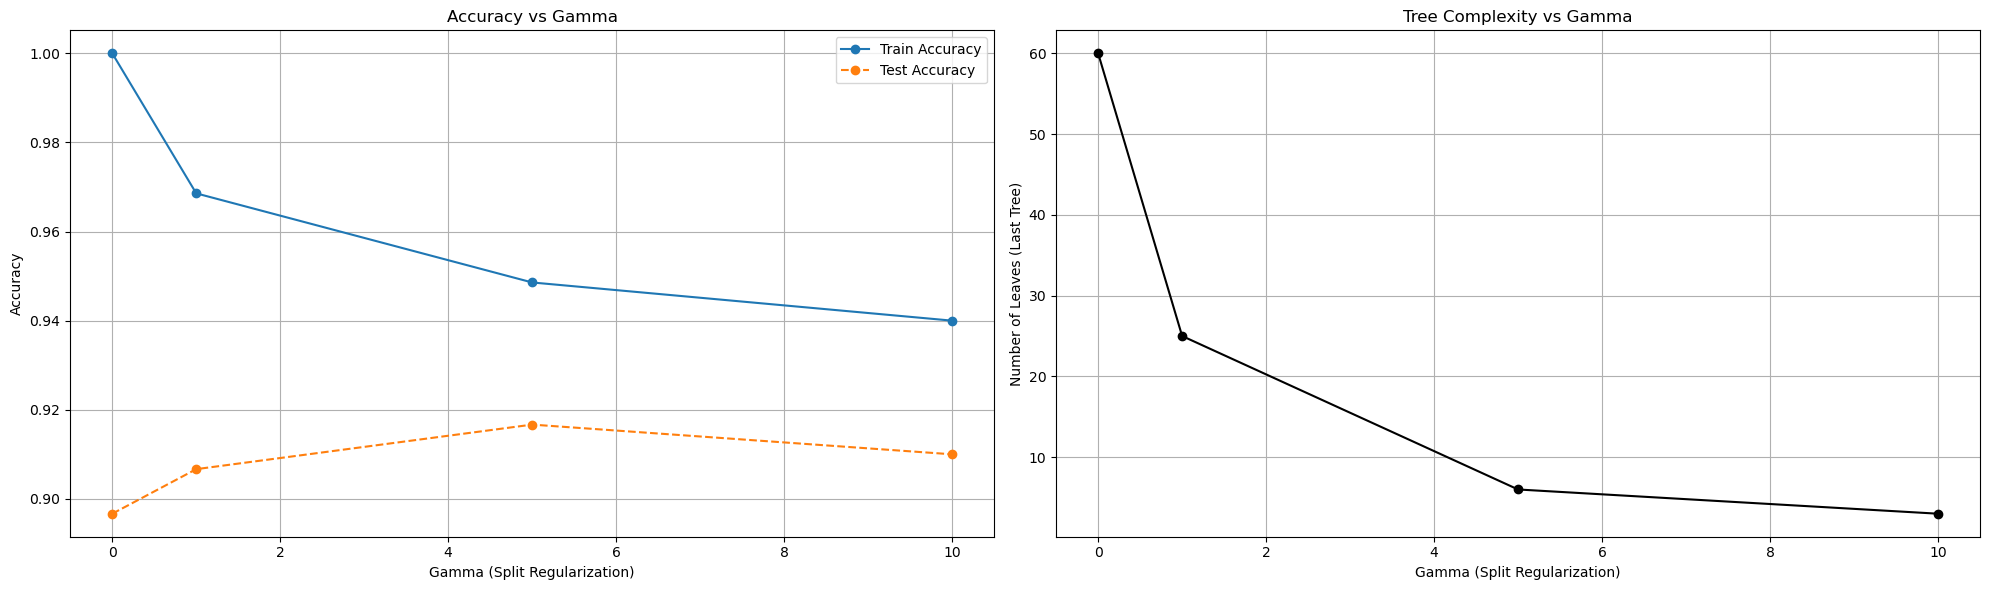

In [196]:

# Results
plt.figure(figsize=(20,6))

# Accuracy
plt.subplot(1,2,1)
plt.plot(gammas, train_accs, marker='o', label="Train Accuracy")
plt.plot(gammas, test_accs, marker='o', linestyle='--', label="Test Accuracy")
plt.xlabel("Gamma (Split Regularization)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Gamma")
plt.legend()
plt.grid(True)

# Leaf Count
plt.subplot(1,2,2)
plt.plot(gammas, leaf_counts, marker='o',color='black')
plt.xlabel("Gamma (Split Regularization)")
plt.ylabel("Number of Leaves (Last Tree)")
plt.title("Tree Complexity vs Gamma")
plt.grid(True)

plt.tight_layout()
plt.show()


---

## 6. Observations

- Increasing $\gamma$ increases the minimum gain required for a split
- This directly reduces the number of splits and hence the number of leaves

$$
\gamma \uparrow \Rightarrow \text{fewer splits} \Rightarrow \text{fewer leaves}
$$

- Accuracy follows a bias-variance tradeoff:

$$
\text{Low } \gamma \Rightarrow \text{low bias, high variance (overfitting)}
$$

$$
\text{High } \gamma \Rightarrow \text{high bias, low variance (underfitting)}
$$

---

## 7. Intuition

$\gamma$ can be interpreted as a threshold on how much improvement is required to justify a split.

- Small $\gamma$:  
  Even small improvements are accepted  

- Large $\gamma$:  
  Only significant improvements are allowed  

---

## 8. Conclusion

- $\gamma$ directly controls tree complexity by regulating splits  
- It is a structural regularization parameter  
- Proper tuning of $\gamma$ leads to better generalization performance  

$$
\text{Optimal } \gamma \Rightarrow \text{balance between underfitting and overfitting}
$$